In [1]:
import numpy as np
import matplotlib.pyplot as plt
import zarr
import os
import glob

import os
import sys

sys.path.append(os.path.abspath(".."))

from src import get_params as gp

plt.style.use('../../my_style.mplstyle')


path = r"/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5/seed*.zarr"

Ps = []

for seed in glob.glob(path):
    polar_path = os.path.join(seed, 'local_polar.zarr')
    polar_zarr = zarr.open(polar_path, mode = 'r')
    polar_orders = polar_zarr[:]

    Ps.append(polar_orders)

Ps_array = np.array(Ps)

Cs = []

for seed in glob.glob(path):
    counts_path = os.path.join(seed, 'counts.zarr')
    counts_zarr = zarr.open(counts_path, mode = 'r')
    counts = counts_zarr[:]

    Cs.append(counts)

Cs_array = np.array(Cs)

params = gp.get_params('/Volumes/data/Sasaki/backup_git/MTCargoSim/data/MTC/P0.5_A0.5/seed1.zarr')

pf = params['packing_fraction']
L = params['box_size']
r_int = params['r_int']
N=int(pf*L*L/ (np.pi * r_int**2))
print(N)

4074


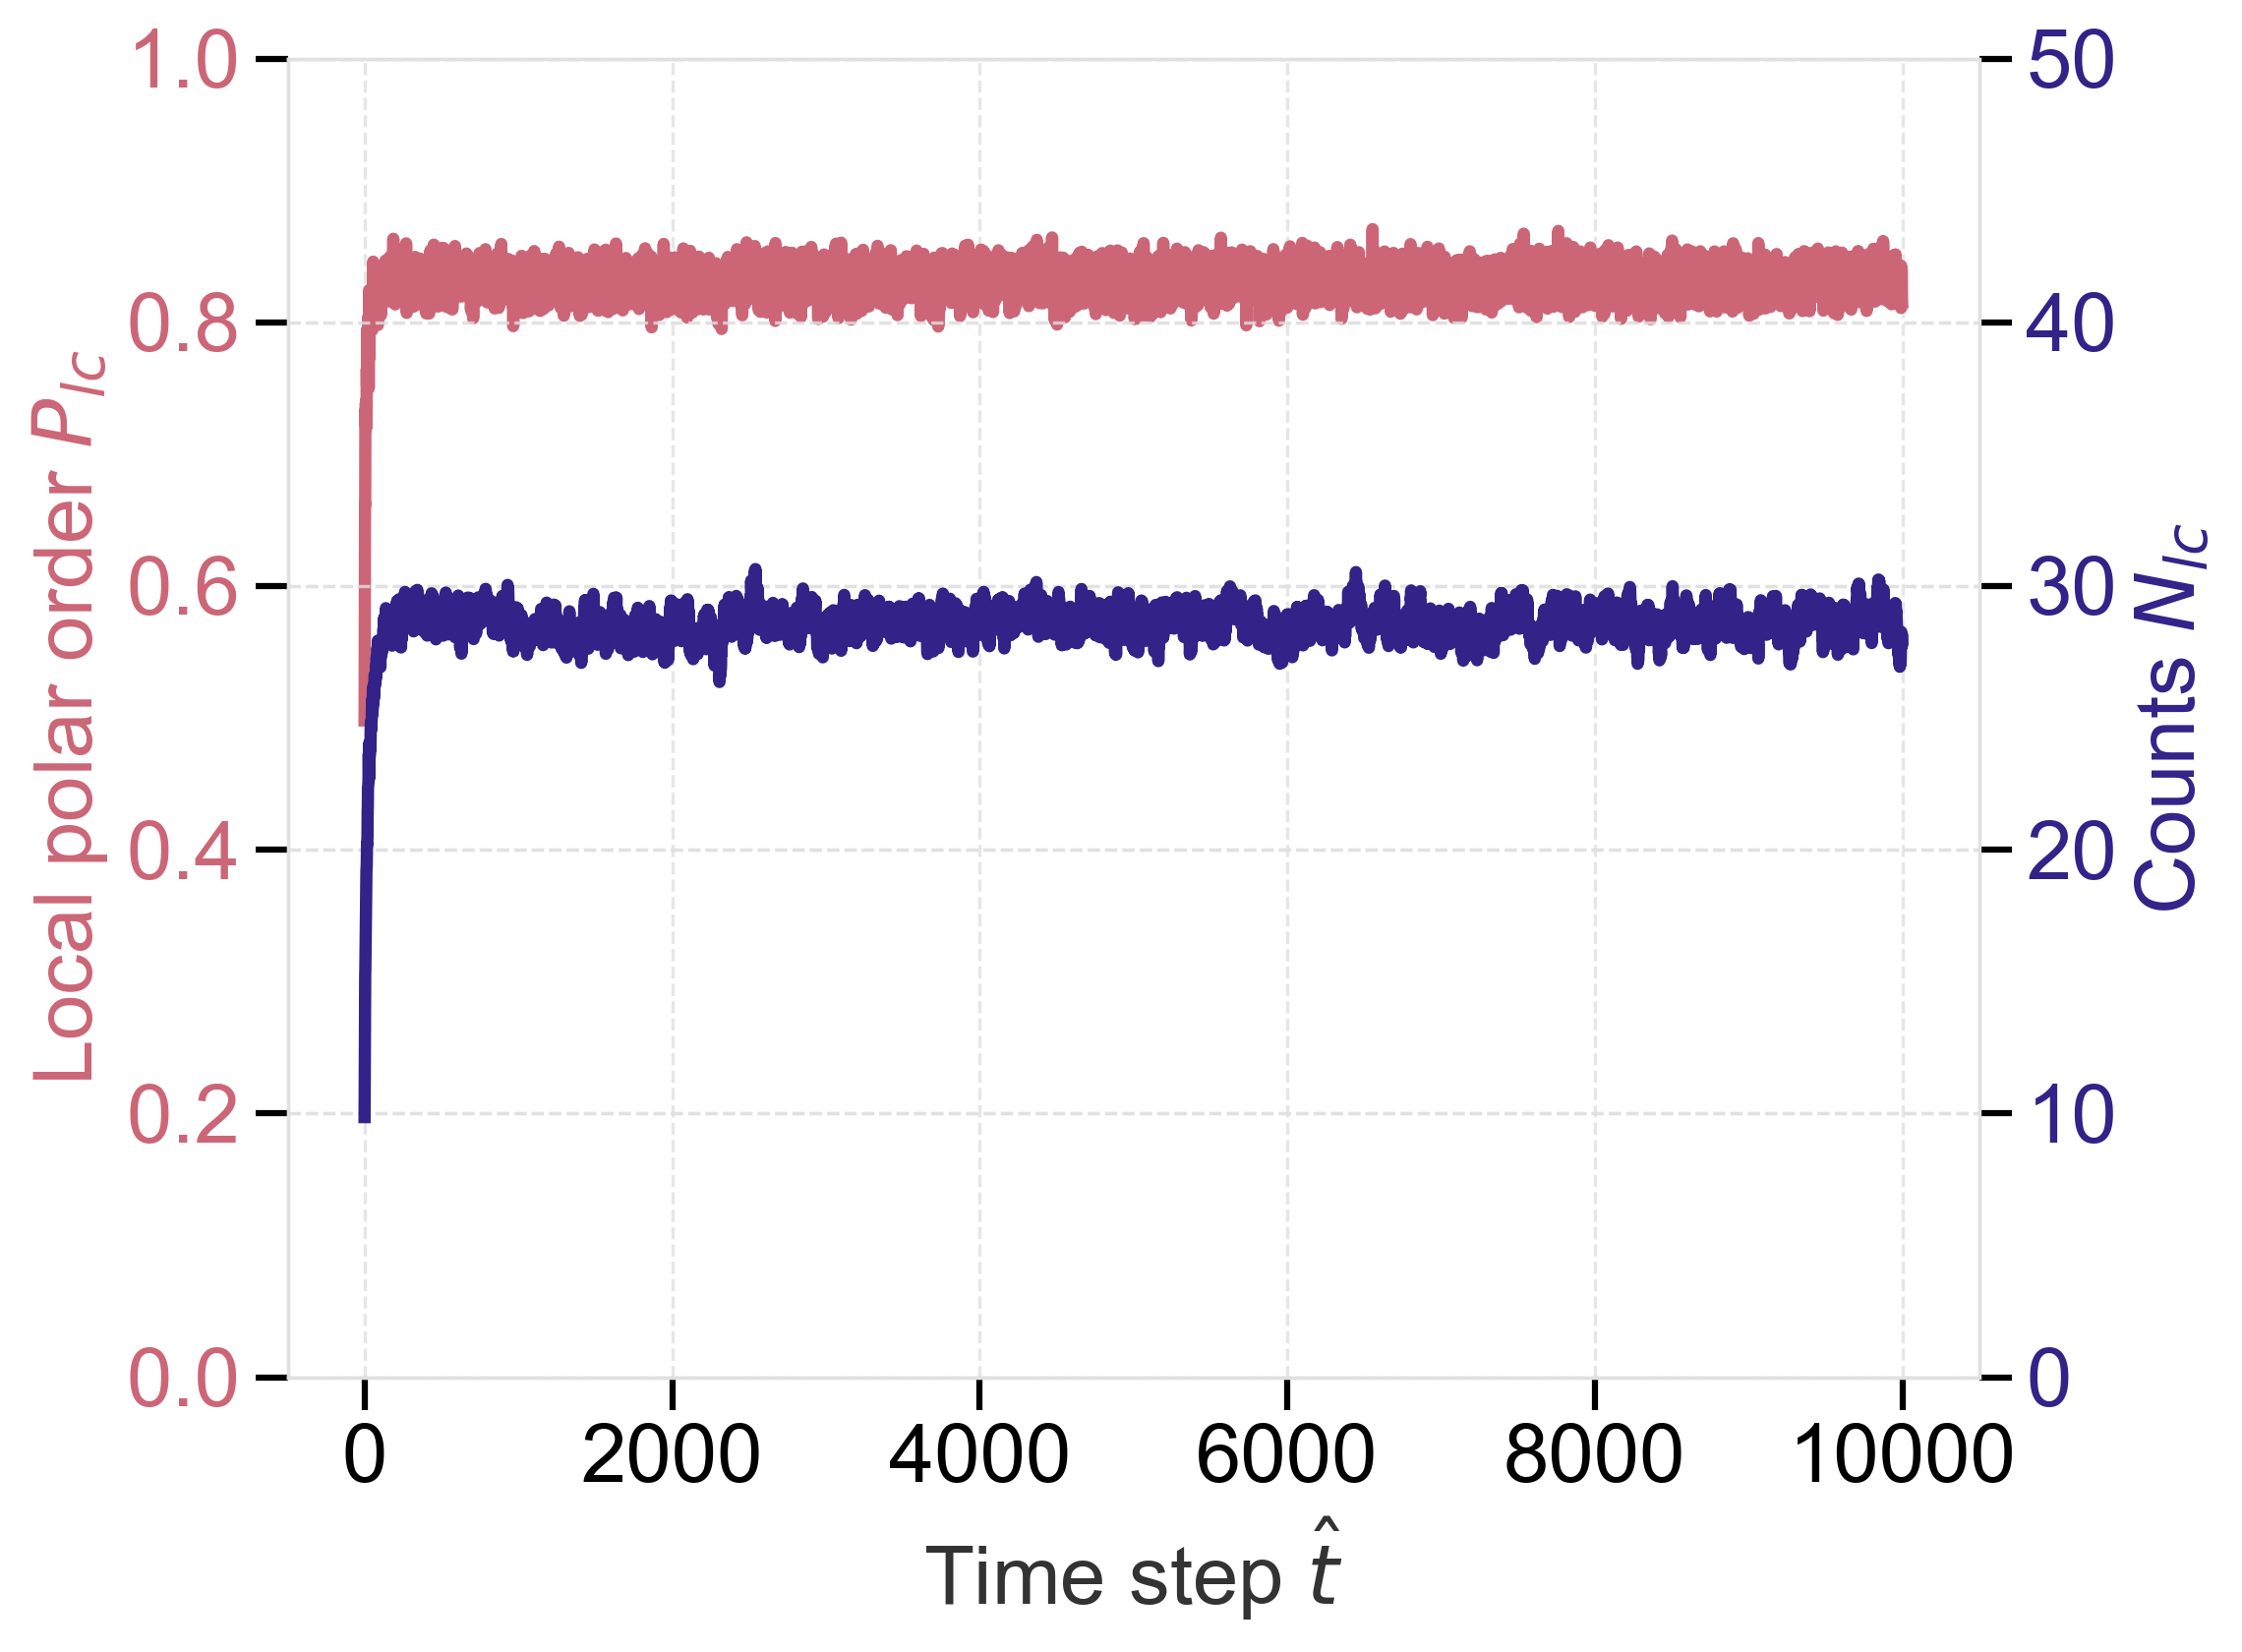

In [ ]:
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax1 = plt.subplots()

# ax1とax2を関連させる
ax2 = ax1.twinx()

t = np.arange(0, Ps_array.shape[1], 1)

Pmean = np.mean(Ps_array, axis = 0)
Cmean = np.mean(Cs_array, axis = 0)

Pstd = np.std(Ps_array, axis = 0)
Cstd = np.std(Cs_array, axis = 0)

ax1.plot(t, Pmean, color = style_colors[0])
ax2.plot(t, Cmean, color = style_colors[1])

#ax1.fill_between(t, Pmean-Pstd, Pmean+Pstd, alpha= 0.2, color = style_colors[0])
#ax2.fill_between(t, Cmean/N-Cstd/N, Cmean/N+Cstd/N, alpha= 0.2, color = style_colors[1])

ax1.set(
    ylim = (0.0, 1.0),
    xlabel = 'Time step $\hat{t}$'
     )
ax1.set_ylabel(ylabel = 'Local polar order $P_{lc}$', color = style_colors[0])
ax1.tick_params(axis='y', labelcolor=style_colors[0])

ax2.set(
    ylim = (0.0, 50),
    xlabel = 'Time step $\hat{t}$'
    )
ax2.set_ylabel(ylabel = 'Counts', color = style_colors[1])
ax2.tick_params(axis='y', labelcolor=style_colors[1])

cd=os.getcwd()

fig.savefig(f"{cd}/figure/Plc.png")
fig.savefig(f"{cd}/figure/Plc.pdf")